# Healthcare Fraud Detection Using Machine Learning
This notebook develops an end-to-end machine learning workflow for identifying potentially fraudulent healthcare claims. The analysis covers data inspection, feature engineering, preprocessing, class-imbalance handling, model development, hyperparameter tuning, validation, threshold optimization, and final evaluation on unseen test data.

Three supervised classification algorithms are developed and compared: **Logistic Regression, Random Forest, and Gradient Boosting**. Their predictions are subsequently combined using a **Soft Voting Ensemble** to assess whether combining complementary models provides a stronger fraud detection solution.

## Project Objectives

- Inspect and understand the healthcare claims dataset.
- Identify data quality issues, including missing values and duplicate records.
- Engineer meaningful features from claim dates and financial information.
- Separate predictors from the fraud target variable.
- Build a reproducible preprocessing pipeline for numerical and categorical variables.
- Address class imbalance using model-level class weighting where supported.
- Train and tune Logistic Regression, Random Forest, and Gradient Boosting using cross-validation.
- Compare models using Precision, Recall, F1-Score, Balanced Accuracy, ROC-AUC, and PR-AUC.
- Build and evaluate a Soft Voting Ensemble.
- Optimize the classification threshold using validation data.
- Evaluate the final approach on an untouched test set.
- Select the final model based on the documented test-set comparison.

## Evaluation Strategy

For fraud detection, a model should not be judged by accuracy alone. **Recall** measures the ability to identify fraudulent claims, while **Precision** measures how many claims flagged as fraudulent are actually fraud. **F1-Score** balances these two objectives. Balanced Accuracy accounts for both classes, while ROC-AUC and PR-AUC provide threshold independent views of classification performance.

# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Load and Understand data

In [2]:
df = pd.read_csv("healthcare_fraud_detection.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10000, 20)


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Information:")
df.info()

Rows: 10000
Columns: 20

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_C

# Data quality Assessment

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Missing Values:
Provider_ID                                0
Claim_ID                                   0
Patient_Age                                0
Patient_Gender                             0
Diagnosis_Code                             0
Procedure_Code                             0
Claim_Amount                               0
Approved_Amount                            0
Insurance_Type                           350
Claim_Submission_Date                      0
Days_Between_Service_and_Claim             0
Number_of_Claims_Per_Provider_Monthly      0
Provider_Specialty                       350
Patient_State                              0
Claim_Status                               0
Is_Fraud                                   0
Length_of_Stay                             0
Visit_Type                                 0
Chronic_Condition_Flag                     0
Prior_Visits_12m                         350
dtype: int64

Duplicate Rows: 0


# Target Distribution and Class Imbalance

In [5]:
print(df["Is_Fraud"].value_counts())

print("\nPercentage:")
print(df["Is_Fraud"].value_counts(normalize=True) * 100)

Is_Fraud
0    9171
1     829
Name: count, dtype: int64

Percentage:
Is_Fraud
0    91.71
1     8.29
Name: proportion, dtype: float64


# Visualising the Target Distribution

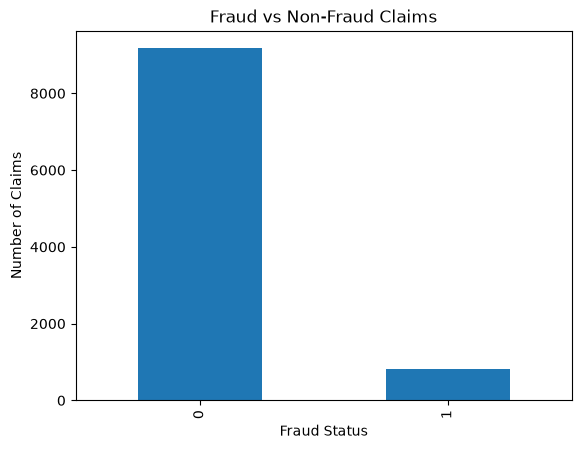

In [6]:
df["Is_Fraud"].value_counts().plot(
    kind="bar",
    title="Fraud vs Non-Fraud Claims"
)

plt.xlabel("Fraud Status")
plt.ylabel("Number of Claims")
plt.show()

# Feature Engineering
The original claim submission date is transformed into separate temporal features: year, month, day, and day of the week. These variables allow the models to use potentially useful temporal patterns without directly passing the raw date field into the modelling pipeline.

In [7]:
df["Claim_Submission_Date"] = pd.to_datetime(
    df["Claim_Submission_Date"],
    errors="coerce"
)

df["Claim_Year"] = df["Claim_Submission_Date"].dt.year
df["Claim_Month"] = df["Claim_Submission_Date"].dt.month
df["Claim_Day"] = df["Claim_Submission_Date"].dt.day
df["Claim_DayOfWeek"] = df["Claim_Submission_Date"].dt.dayofweek

In [8]:
df["Amount_Difference"] = (
    df["Claim_Amount"] - df["Approved_Amount"]
)

In [9]:
df["Approval_Ratio"] = (
    df["Approved_Amount"] /
    df["Claim_Amount"].replace(0, np.nan)
)

# Removing Identifier and Raw Date Fields

The claim identifier and original submission-date field are removed after the useful date-derived features have been created. This prevents raw identifiers and the unprocessed date from being used directly as predictive variables.

In [10]:
df = df.drop(
    columns=[
        "Claim_ID",
        "Claim_Submission_Date"
    ]
)

# Removing Provider Identifier

The provider identifier is excluded from the feature set. This avoids allowing a raw identifier to act as a direct model input and keeps the modelling data focused on claim level characteristics represented by the remaining variables.


In [11]:
df = df.drop(columns=["Provider_ID"])

In [12]:
df.head()

,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,...,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m,Claim_Year,Claim_Month,Claim_Day,Claim_DayOfWeek,Amount_Difference,Approval_Ratio
0,37,Male,I25.10,36415,443.51,393.16,Medicaid,13,70,Cardiology,...,0,Outpatient,1,2.0,2024,9,1,6,50.35,0.886474
1,21,Female,E11.9,99213,467.50,461.33,Self-Pay,5,62,General Practice,...,5,Inpatient,1,2.0,2022,9,5,0,6.17,0.986802
2,78,Female,J06.9,93000,591.69,530.06,Medicaid,29,60,Cardiology,...,5,Inpatient,1,3.0,2022,4,11,0,61.63,0.895841
3,65,Male,I10,93000,235.15,189.11,Private,22,70,General Practice,...,0,Emergency,0,5.0,2023,10,11,2,46.04,0.804210
4,36,Male,M54.5,85025,487.96,369.91,Private,21,67,Pulmonology,...,5,Inpatient,0,4.0,2023,9,5,1,118.05,0.758074


#  Define Features and Target

The dataset is separated into predictor variables (`X`) and the target variable (`y`). `X` contains the information available to the models, while `y` represents whether each claim is labelled as fraudulent.

In [13]:
X = df.drop("Is_Fraud", axis=1)

y = df["Is_Fraud"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 22)
Target: (10000,)


# Identify Numerical and Categorical Features

The predictors are divided into numerical and categorical variables. This distinction is required because the two feature types need different preprocessing operations before they can be supplied consistently to the machine learning algorithms.

In [14]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Patient_Gender', 'Diagnosis_Code', 'Insurance_Type', 'Provider_Specialty', 'Patient_State', 'Claim_Status', 'Visit_Type']

Numerical Features:
['Patient_Age', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount', 'Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly', 'Length_of_Stay', 'Chronic_Condition_Flag', 'Prior_Visits_12m', 'Claim_Year', 'Claim_Month', 'Claim_Day', 'Claim_DayOfWeek', 'Amount_Difference', 'Approval_Ratio']


# Train, Validation, and Test Split

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)
print("Testing:", X_test.shape)

Training: (6000, 22)
Validation: (2000, 22)
Testing: (2000, 22)


# Preprocessing 

In [16]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Logistic Regression

In [17]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

# Logistic Regression Hyperparameter 

In [18]:
logistic_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

# Tune Logistic Regression Using Cross-Validation

In [19]:
logistic_grid = GridSearchCV(
    logistic_pipeline,
    logistic_params,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

logistic_grid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see

 # Review the Best Logistic Regression Configuration

In [20]:
print("Best Logistic Parameters:")
print(logistic_grid.best_params_)

print("\nBest CV F1 Score:")
print(logistic_grid.best_score_)

Best Logistic Parameters:
{'model__C': 10, 'model__solver': 'liblinear'}

Best CV F1 Score:
0.9449294659728519


# Store the Tuned Logistic Regression Model

In [21]:
logistic_model = logistic_grid.best_estimator_

# Random Forest 

In [22]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

 # Random Forest Hyperparameter Search Space

In [23]:
rf_params = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

 # Tune Random Forest Using Cross-Validation

In [24]:
rf_grid = GridSearchCV(
    random_forest_pipeline,
    rf_params,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [200, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`

#  Best Random Forest Configuration

In [26]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV F1 Score:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Best CV F1 Score:
0.969674846689361


# Store the Tuned Random Forest Model

In [27]:
random_forest_model = rf_grid.best_estimator_

# Gradient Boosting 

In [28]:
gradient_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

#  Gradient Boosting Hyperparameter Search Space

In [29]:
gradient_params = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [2, 5]
}

# Tune Gradient Boosting Using Cross-Validation

In [30]:
gradient_grid = GridSearchCV(
    gradient_pipeline,
    gradient_params,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

gradient_grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3], 'model__min_samples_leaf': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sp

# Best Gradient Boosting Configuration

In [31]:
print("Best Gradient Boosting Parameters:")
print(gradient_grid.best_params_)

print("\nBest CV F1 Score:")
print(gradient_grid.best_score_)

Best Gradient Boosting Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}

Best CV F1 Score:
0.9793901591172226


In [58]:
# Store the Tuned Gradient Boosting Model

In [32]:
gradient_model = gradient_grid.best_estimator_

# Model Evaluation Function

In [33]:
def evaluate_model(model, X_data, y_data, threshold=0.5):

    probabilities = model.predict_proba(X_data)[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    return {
        "Accuracy": accuracy_score(y_data, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_data, predictions),
        "Precision": precision_score(y_data, predictions, zero_division=0),
        "Recall": recall_score(y_data, predictions, zero_division=0),
        "F1 Score": f1_score(y_data, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_data, probabilities),
        "PR-AUC": average_precision_score(y_data, probabilities)
    }

# Compare Models

In [34]:
results = []

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_model
}

for name, model in models.items():

    scores = evaluate_model(
        model,
        X_valid,
        y_valid
    )

    scores["Model"] = name

    results.append(scores)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ]
]

results_df.sort_values(
    "F1 Score",
    ascending=False
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
2,Gradient Boosting,0.994,0.966595,0.993590,0.933735,0.962733,0.998377,0.987725
1,Random Forest,0.993,0.971528,0.969136,0.945783,0.957317,0.998156,0.987856
0,Logistic Regression,0.985,0.961688,0.890805,0.933735,0.911765,0.997044,0.978145


# Soft Voting Ensemble

In [37]:
ensemble = VotingClassifier(
    estimators=[
        ("logistic", logistic_model),
        ("random_forest", random_forest_model),
        ("gradient_boosting", gradient_model)
    ],
    voting="soft",
    weights=[1, 2, 2]
)

# Train Ensemble

In [38]:
ensemble.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('logistic', ...), ('random_forest', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[1, 2, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[Pipeline(step...liblinear'))]), Pipeline(step...m_state=42))]), Pipeline(step...m_state=42))])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Patient_Age','Patient_Gender','Diagnosis_Code',...,'Claim_DayOfWeek', 'Amount_Difference','Approval_Ratio']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


# Evaluate Ensemble

In [39]:
ensemble_scores = evaluate_model(
    ensemble,
    X_valid,
    y_valid
)

ensemble_scores

{'Accuracy': 0.9945,
 'Balanced Accuracy': 0.9696068899370656,
 'Precision': 0.9936305732484076,
 'Recall': 0.9397590361445783,
 'F1 Score': 0.9659442724458205,
 'ROC-AUC': 0.9979799240582833,
 'PR-AUC': 0.9861309513862039}

# THRESHOLD TUNING
The default threshold is:

Probability >= 0.50 → Fraud
Probability < 0.50 → Not Fraud

But for fraud detection, 0.50 isn't automatically the best threshold.

We'll find the threshold that gives the best F1 score on the validation set.

In [40]:
# best threshold
validation_probabilities = ensemble.predict_proba(
    X_valid
)[:, 1]

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.01):

    predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_valid,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_valid,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_valid,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best Threshold:", best_threshold)
print("Best Validation F1:", best_threshold_row["F1"])

Best Threshold: 0.48999999999999977
Best Validation F1: 0.9659442724458205


# Visualize Threshold Performance

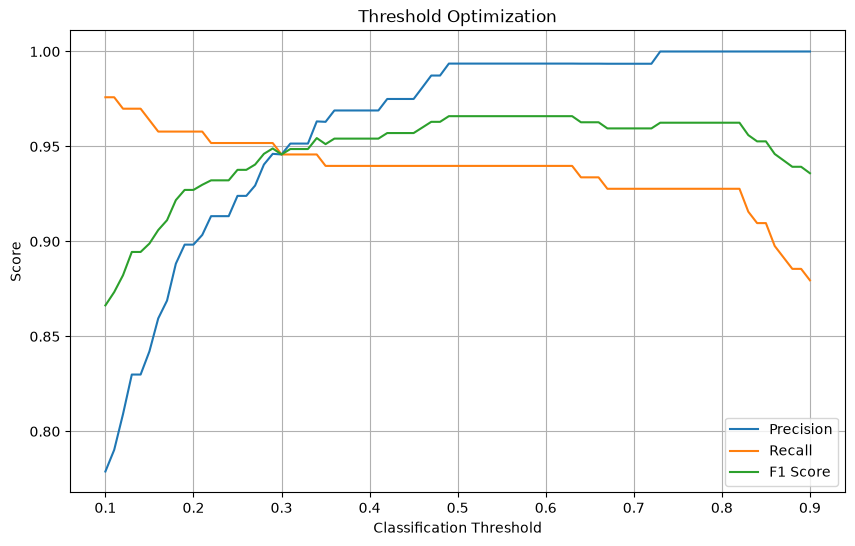

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()
plt.grid()
plt.show()

# Final Ensemble Prediction

In [42]:
test_probabilities = ensemble.predict_proba(
    X_test
)[:, 1]

test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

# Final Performance

In [43]:
final_results = {
    "Accuracy": accuracy_score(
        y_test,
        test_predictions
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_test,
        test_predictions
    ),

    "Precision": precision_score(
        y_test,
        test_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        test_predictions,
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_test,
        test_predictions,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        test_probabilities
    ),

    "PR-AUC": average_precision_score(
        y_test,
        test_probabilities
    )
}

final_results_df = pd.DataFrame(
    [final_results]
)

final_results_df

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,0.9955,0.975631,0.993711,0.951807,0.972308,0.999353,0.99519


# Classification Report

In [44]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Non-Fraud",
            "Fraud"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

   Non-Fraud     0.9957    0.9995    0.9976      1834
       Fraud     0.9937    0.9518    0.9723       166

    accuracy                         0.9955      2000
   macro avg     0.9947    0.9756    0.9849      2000
weighted avg     0.9955    0.9955    0.9955      2000



# Confusion Matrix

In [45]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1833    1]
 [   8  158]]


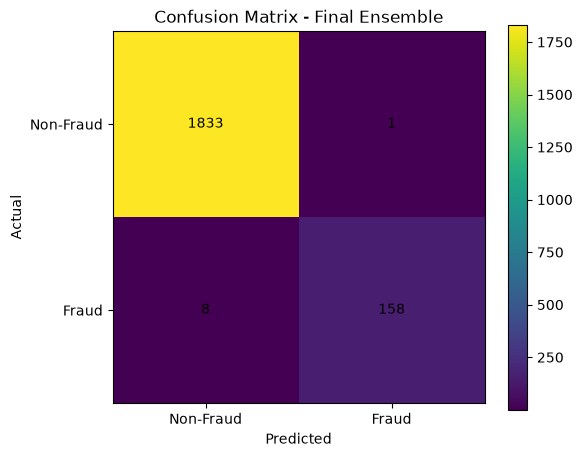

In [46]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Final Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Non-Fraud", "Fraud"]
)

plt.yticks(
    [0, 1],
    ["Non-Fraud", "Fraud"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

# ROC Curve

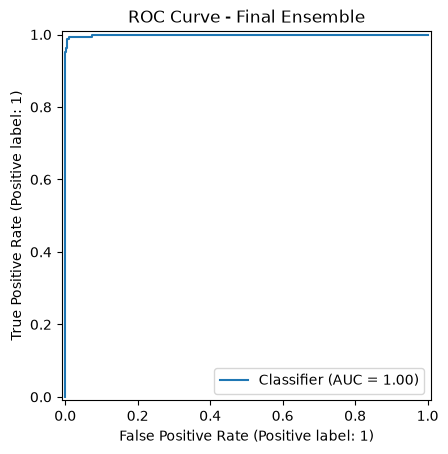

In [47]:
RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities
)

plt.title("ROC Curve - Final Ensemble")
plt.show()

# Precision-Recall Curve

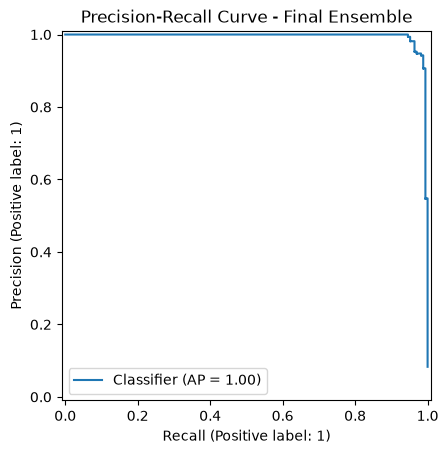

In [48]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities
)

plt.title("Precision-Recall Curve - Final Ensemble")
plt.show()

# Compare All Models

In [49]:
comparison = results_df.copy()

ensemble_row = pd.DataFrame([{
    "Model": "Voting Ensemble",
    "Accuracy": final_results["Accuracy"],
    "Balanced Accuracy": final_results["Balanced Accuracy"],
    "Precision": final_results["Precision"],
    "Recall": final_results["Recall"],
    "F1 Score": final_results["F1 Score"],
    "ROC-AUC": final_results["ROC-AUC"],
    "PR-AUC": final_results["PR-AUC"]
}])

comparison = pd.concat(
    [comparison, ensemble_row],
    ignore_index=True
)

comparison.sort_values(
    "F1 Score",
    ascending=False
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
3,Voting Ensemble,0.9955,0.975631,0.993711,0.951807,0.972308,0.999353,0.995190
2,Gradient Boosting,0.9940,0.966595,0.993590,0.933735,0.962733,0.998377,0.987725
1,Random Forest,0.9930,0.971528,0.969136,0.945783,0.957317,0.998156,0.987856
0,Logistic Regression,0.9850,0.961688,0.890805,0.933735,0.911765,0.997044,0.978145


# Visual Model Comparison

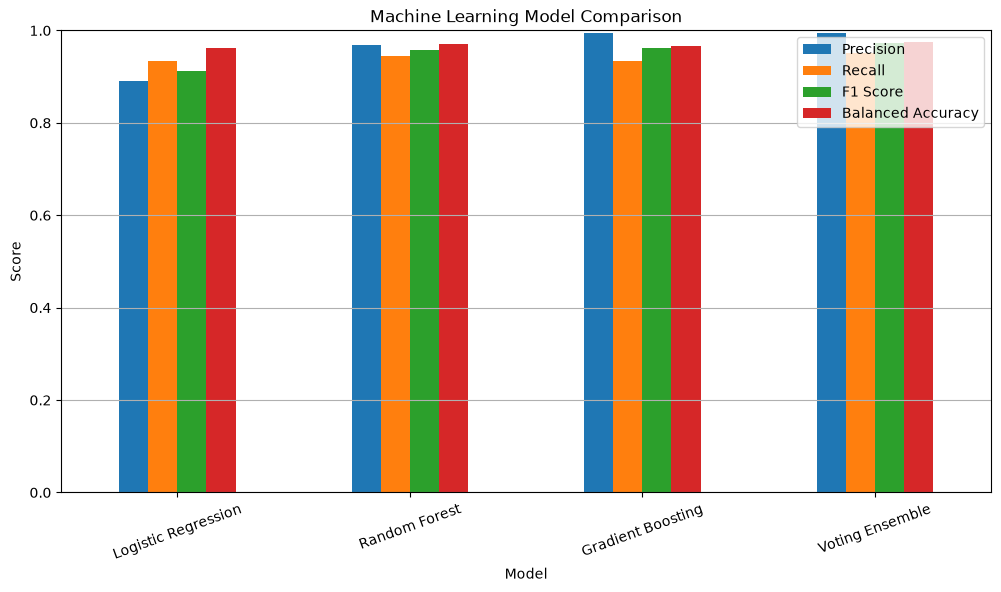

In [50]:
comparison_plot = comparison.set_index("Model")[
    [
        "Precision",
        "Recall",
        "F1 Score",
        "Balanced Accuracy"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend()
plt.grid(axis="y")
plt.show()

# Final Model Decision

In [51]:
best_model_name = comparison.loc[
    comparison["F1 Score"].idxmax(),
    "Model"
]

print("FINAL SELECTED MODEL:", best_model_name)

FINAL SELECTED MODEL: Voting Ensemble


In [52]:
print("\nFinal Decision Threshold:", round(best_threshold, 2))

print("\nFinal Test Performance:")

for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")


Final Decision Threshold: 0.49

Final Test Performance:
Accuracy: 0.9955
Balanced Accuracy: 0.9756
Precision: 0.9937
Recall: 0.9518
F1 Score: 0.9723
ROC-AUC: 0.9994
PR-AUC: 0.9952


# Fraud Risk Prediction Function

In [53]:
def predict_fraud(claim_data):

    probability = ensemble.predict_proba(
        claim_data
    )[:, 1][0]

    prediction = int(
        probability >= best_threshold
    )

    if prediction == 1:
        result = "FRAUD RISK"
    else:
        result = "LOW FRAUD RISK"

    return result, probability

In [54]:
sample_claim = X_test.iloc[[0]]

result, probability = predict_fraud(
    sample_claim
)

print("Prediction:", result)
print("Fraud Probability:", round(probability, 4))

Prediction: LOW FRAUD RISK
Fraud Probability: 0.0014


# Conclusion

This project developed a machine learning approach for identifying potentially fraudulent healthcare claims. The workflow included data quality assessment, feature engineering, preprocessing, class-imbalance handling, model tuning, threshold optimization, and evaluation on an unseen test set. The final Soft Voting Ensemble achieved 99.55% accuracy, 99.37% precision, 95.18% recall, and an F1-score of 97.23%, with a ROC-AUC of 99.94% and PR-AUC of 99.52%. These results indicate that the developed approach can effectively distinguish fraudulent and non-fraudulent claims within the dataset and can serve as a decision support tool for prioritising claims for further review.


# Limitations

The main limitation is that the model was evaluated on a single dataset containing 10,000 claims, so its performance may not generalise to real healthcare claims from different organisations or populations. The fraud labels are also assumed to represent the ground truth and may not capture all real world fraud patterns. The dataset contains relatively few fraudulent claims compared with non-fraudulent claims, which makes fraud detection more challenging. In addition, the model identifies statistical patterns rather than proving that a claim is fraudulent; therefore, predictions should support human investigation rather than replace it. External validation on larger, real world datasets would be required before operational use.
